<a href="https://colab.research.google.com/github/jahnavib529/Deep-learning/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learned Parameters:
Bias = 4.215096094633133
Weight = 2.7701134419877866

Final Loss: 0.4032922819835273


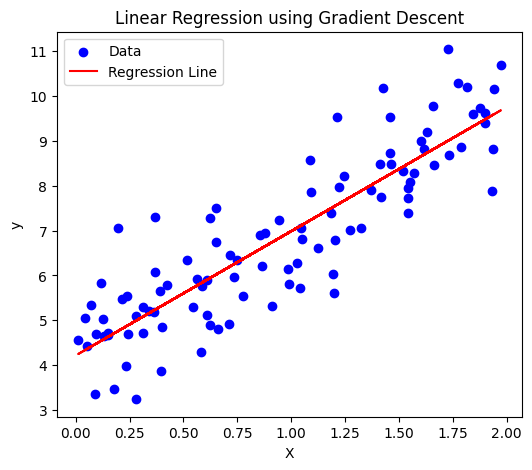

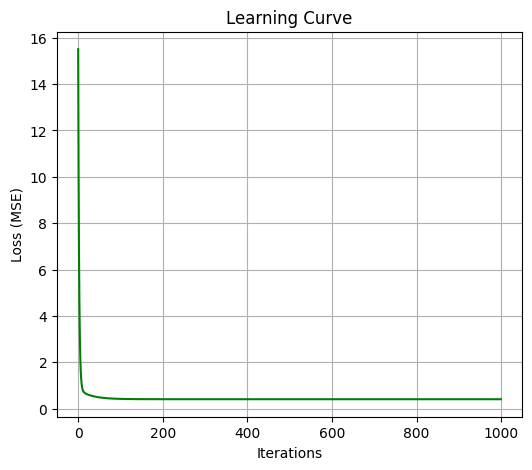

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

theta = np.random.randn(2, 1)
learning_rate = 0.1
iterations = 1000
m = len(X)

loss_history = []
for i in range(iterations):
    predictions = X_b.dot(theta)

    loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    loss_history.append(loss)
    gradients = (1 / m) * X_b.T.dot(predictions - y)
    theta = theta - learning_rate * gradients

print("Learned Parameters:")
print("Bias =", theta[0][0])
print("Weight =", theta[1][0])

print("\nFinal Loss:", loss_history[-1])

plt.figure(figsize=(6,5))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X_b.dot(theta), color='red', label='Regression Line')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(range(iterations), loss_history, color='green')
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

Actual Mean: 10
Estimated Mean (MLE): 10.038664111644652

Actual Variance: 4
Estimated Variance (MLE): 3.8316199589260687


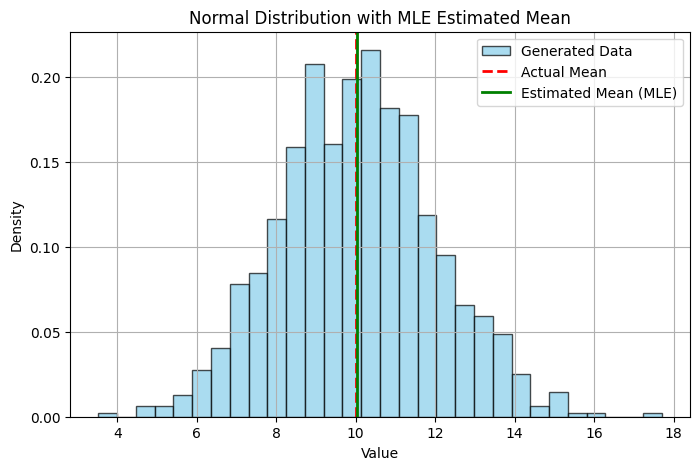

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
true_mean = 10
true_variance = 4
true_std = np.sqrt(true_variance)
data = np.random.normal(loc=true_mean, scale=true_std, size=1000)

estimated_mean = np.mean(data)
estimated_variance = np.mean((data - estimated_mean) ** 2)

print("Actual Mean:", true_mean)
print("Estimated Mean (MLE):", estimated_mean)

print("\nActual Variance:", true_variance)
print("Estimated Variance (MLE):", estimated_variance)

plt.figure(figsize=(8,5))

plt.hist(data, bins=30, density=True, alpha=0.7,
         color='skyblue', edgecolor='black',
         label='Generated Data')

plt.axvline(true_mean, color='red', linestyle='--',
            linewidth=2, label='Actual Mean')

plt.axvline(estimated_mean, color='green', linestyle='-',
            linewidth=2, label='Estimated Mean (MLE)')

plt.title("Normal Distribution with MLE Estimated Mean")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


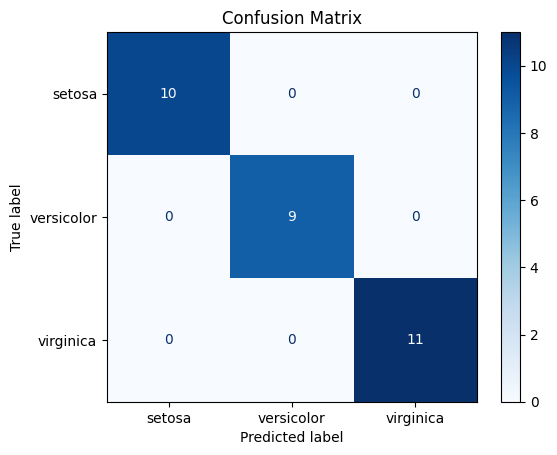

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 1
[1 1] -> 0


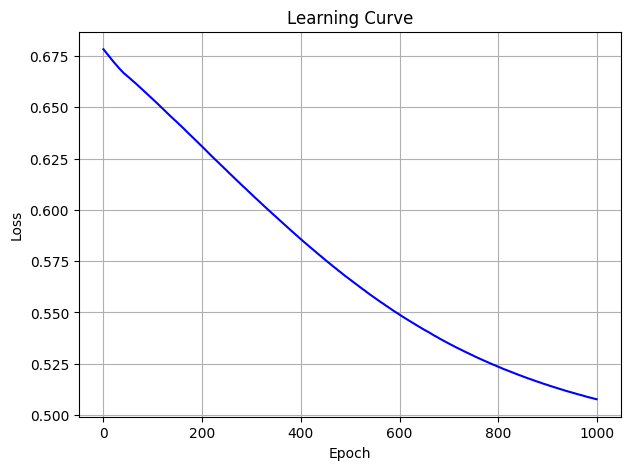

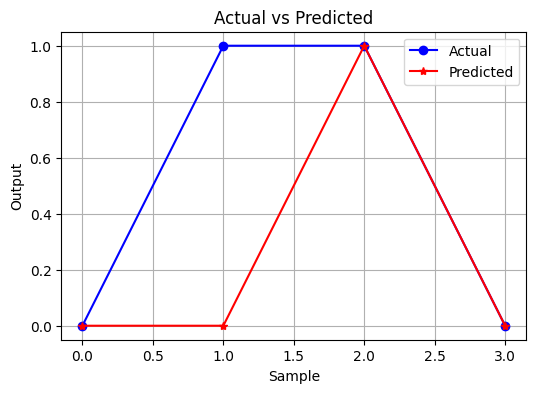

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0,0],[0,1],[1,0],[1,1]])

y = np.array([[0],[1],[1],[0]])

model = Sequential()

model.add(Dense(4, input_dim=2, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit( X, y, epochs=1000, verbose=0)
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Accuracy:", accuracy)

predictions = model.predict(X)

print("\nPredictions:")
for i in range(len(X)):
    print(X[i], "->", round(predictions[i][0]))
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], color='blue')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
plt.figure(figsize=(6,4))

plt.plot(y, 'bo-', label='Actual')
plt.plot(np.round(predictions), 'r*-', label='Predicted')

plt.xlabel("Sample")
plt.ylabel("Output")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

Input	Weighted Sum	Sigmoid		ReLU
-3	-5.00		0.0067		0.00
-2	-3.50		0.0293		0.00
-1	-2.00		0.1192		0.00
0	-0.50		0.3775		0.00
1	1.00		0.7311		1.00
2	2.50		0.9241		2.50
3	4.00		0.9820		4.00


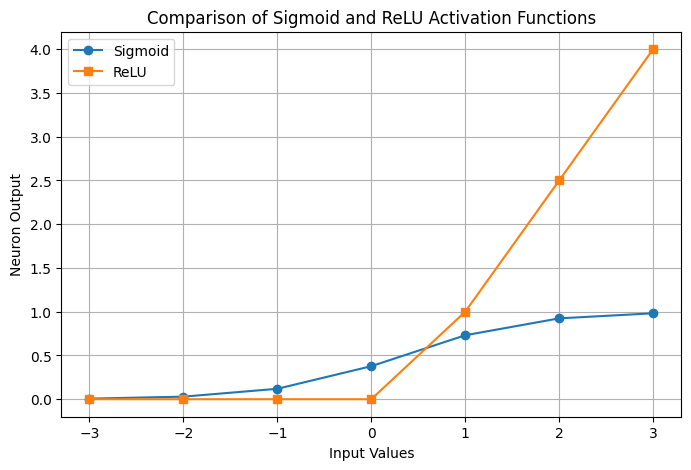

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

inputs = np.array([-3, -2, -1, 0, 1, 2, 3])

weight = 1.5
bias = -0.5

z = weight * inputs + bias
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)
sigmoid_output = sigmoid(z)
relu_output = relu(z)

print("Input\tWeighted Sum\tSigmoid\t\tReLU")

for i in range(len(inputs)):
    print(f"{inputs[i]}\t{z[i]:.2f}\t\t{sigmoid_output[i]:.4f}\t\t{relu_output[i]:.2f}")
plt.figure(figsize=(8,5))

plt.plot(inputs, sigmoid_output, marker='o', label='Sigmoid')
plt.plot(inputs, relu_output, marker='s', label='ReLU')

plt.title("Comparison of Sigmoid and ReLU Activation Functions")
plt.xlabel("Input Values")
plt.ylabel("Neuron Output")
plt.legend()
plt.grid(True)

plt.show()

Perceptron Accuracy: 0.9333333333333333
MLP Accuracy: 1.0


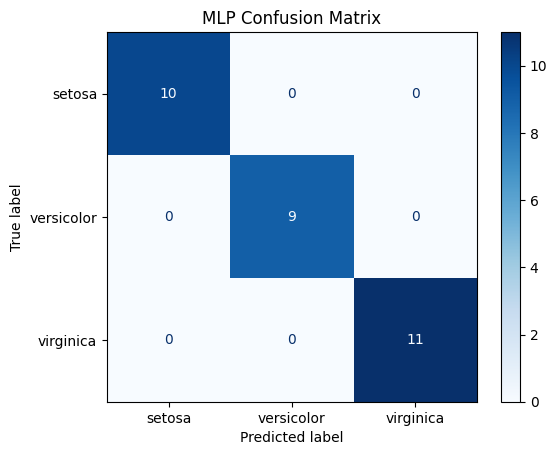

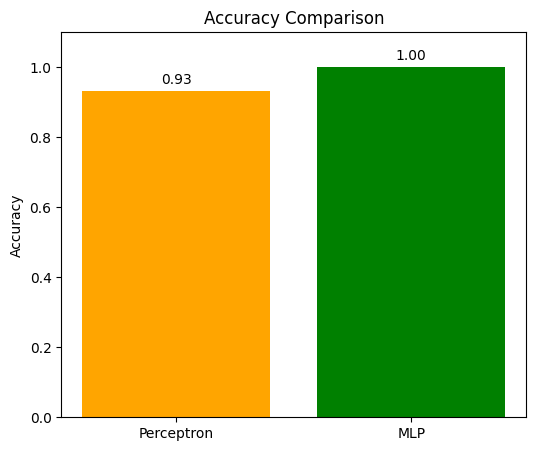

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
perceptron = Perceptron(max_iter=1000, random_state=42)

perceptron.fit(X_train, y_train)

y_pred_p = perceptron.predict(X_test)

acc_p = accuracy_score(y_test, y_pred_p)

print("Perceptron Accuracy:", acc_p)
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("MLP Accuracy:", acc_mlp)
cm = confusion_matrix(y_test, y_pred_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()
models = ['Perceptron', 'MLP']
accuracy = [acc_p, acc_mlp]

plt.figure(figsize=(6,5))
plt.bar(models, accuracy, color=['orange', 'green'])

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
import numpy as np

x = np.array([1, 2])
weights_hidden = np.array([[0.2, 0.4],
                           [0.3, 0.5]])

bias_hidden = np.array([0.1, 0.2])

weights_output = np.array([0.6, 0.7])
bias_output = 0.3

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

hidden_input = np.dot(x, weights_hidden) + bias_hidden
hidden_output = sigmoid(hidden_input)

final_input = np.dot(hidden_output, weights_output) + bias_output
final_output = sigmoid(final_input)

print("Hidden Layer Input :", hidden_input)
print("Hidden Layer Output:", hidden_output)

print("\nOutput Layer Input :", final_input)
print("Final Output       :", final_output)

Hidden Layer Input : [0.9 1.6]
Hidden Layer Output: [0.7109495  0.83201839]

Output Layer Input : 1.3089825711687495
Final Output       : 0.7873428534152332


In [ ]:
import numpy as np
X = np.array([1, 2])
target = 1
weights = np.array([0.1, 0.2])
bias = 0.3

learning_rate = 0.1

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

net = np.dot(X, weights) + bias
output = sigmoid(net)

print("Output before training:", output)

error = target - output

print("Error:", error)

delta = error * sigmoid_derivative(output)

old_weights = weights.copy()
old_bias = bias

weights = weights + learning_rate * delta * X
bias = bias + learning_rate * delta

new_net = np.dot(X, weights) + bias
new_output = sigmoid(new_net)

print("\nWeights Before Update:", old_weights)
print("Bias Before Update:", old_bias)

print("\nWeights After Update:", weights)
print("Bias After Update:", bias)

print("\nOutput after one iteration:", new_output)

Output before training: 0.6899744811276125
Error: 0.3100255188723875

Weights Before Update: [0.1 0.2]
Bias Before Update: 0.3

Weights After Update: [0.10663175 0.21326349]
Bias After Update: 0.3066317464655539

Output after one iteration: 0.698421086579901


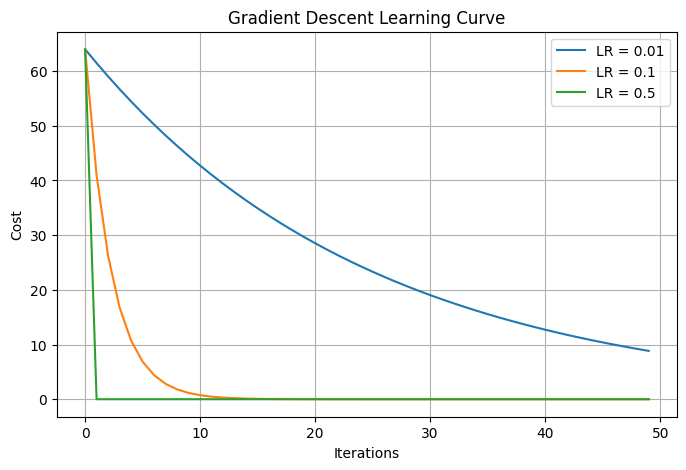

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def cost(x):
    return x**2
def gradient(x):
    return 2 * x
def gradient_descent(learning_rate, iterations):
    x = 8
    cost_history = []

    for i in range(iterations):
        cost_history.append(cost(x))
        x = x - learning_rate * gradient(x)

    return cost_history
learning_rates = [0.01, 0.1, 0.5]

plt.figure(figsize=(8,5))

for lr in learning_rates:
    history = gradient_descent(lr, 50)
    plt.plot(history, label=f"LR = {lr}")

plt.title("Gradient Descent Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)

plt.show()

Batch GD Parameters:
[[4.16104533]
 [2.81783733]]

SGD Parameters:
[[4.31467157]
 [2.56685179]]


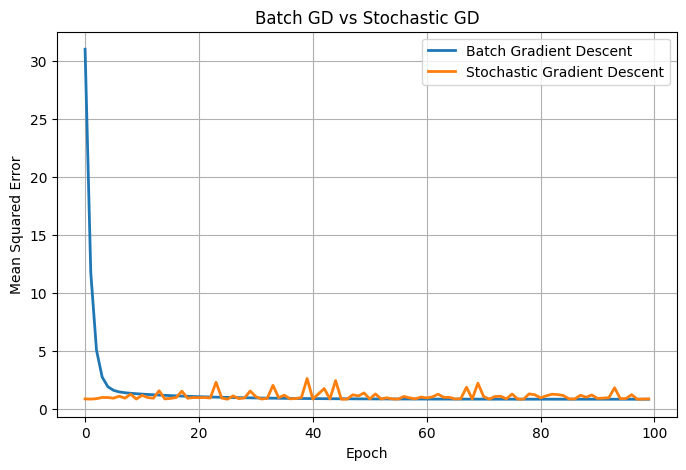

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

theta_batch = np.random.randn(2, 1)
learning_rate = 0.1
epochs = 100

batch_loss = []

m = len(X)

for epoch in range(epochs):

    predictions = X_b.dot(theta_batch)

    loss = np.mean((predictions - y) ** 2)
    batch_loss.append(loss)

    gradients = (2/m) * X_b.T.dot(predictions - y)

    theta_batch = theta_batch - learning_rate * gradients
theta_sgd = np.random.randn(2,1)

sgd_loss = []

for epoch in range(epochs):

    for i in range(m):

        random_index = np.random.randint(m)

        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        prediction = xi.dot(theta_sgd)

        gradients = 2 * xi.T.dot(prediction - yi)

        theta_sgd = theta_sgd - learning_rate * gradients

    predictions = X_b.dot(theta_sgd)
    loss = np.mean((predictions - y) ** 2)
    sgd_loss.append(loss)
print("Batch GD Parameters:")
print(theta_batch)

print("\nSGD Parameters:")
print(theta_sgd)
plt.figure(figsize=(8,5))

plt.plot(batch_loss, label="Batch Gradient Descent", linewidth=2)
plt.plot(sgd_loss, label="Stochastic Gradient Descent", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Batch GD vs Stochastic GD")
plt.legend()
plt.grid(True)

plt.show()

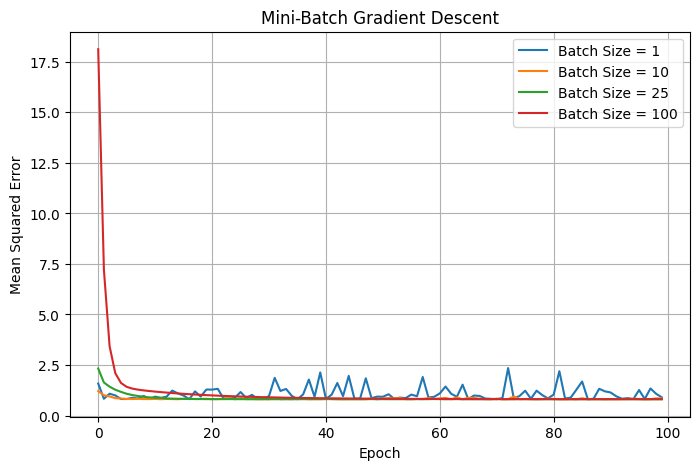

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

def mini_batch_gd(batch_size, learning_rate=0.1, epochs=100):
    theta = np.random.randn(2, 1)
    m = len(X_b)
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_b[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            predictions = X_batch.dot(theta)

            gradients = (2 / len(X_batch)) * X_batch.T.dot(predictions - y_batch)

            theta = theta - learning_rate * gradients
        predictions = X_b.dot(theta)
        loss = np.mean((predictions - y) ** 2)
        loss_history.append(loss)

    return loss_history
batch_sizes = [1, 10, 25, 100]

plt.figure(figsize=(8,5))

for batch in batch_sizes:
    history = mini_batch_gd(batch)
    plt.plot(history, label=f'Batch Size = {batch}')

plt.title("Mini-Batch Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

Dimension = 2, Average Distance = 2.38, Accuracy = 0.953
Dimension = 5, Average Distance = 3.60, Accuracy = 0.947
Dimension = 10, Average Distance = 6.31, Accuracy = 0.867
Dimension = 20, Average Distance = 11.25, Accuracy = 0.947
Dimension = 50, Average Distance = 26.11, Accuracy = 0.927
Dimension = 100, Average Distance = 50.46, Accuracy = 0.913


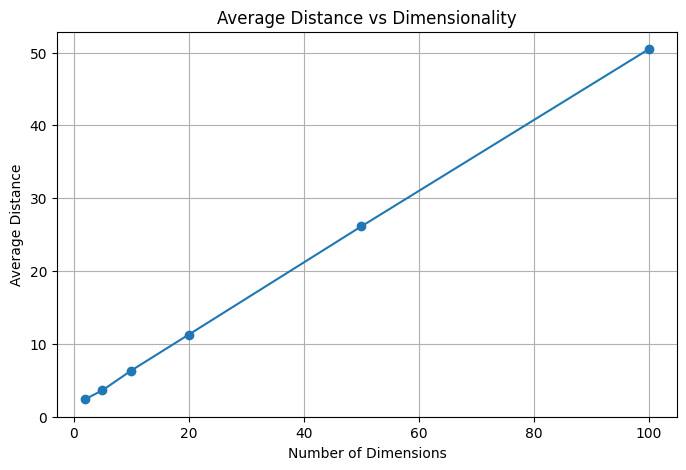

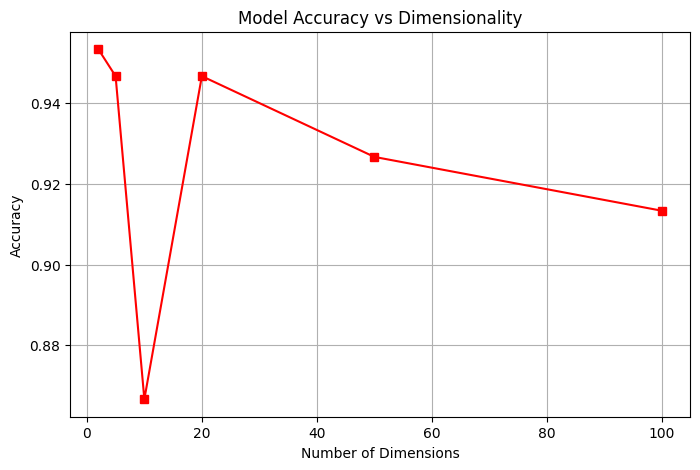

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist

dimensions = [2, 5, 10, 20, 50, 100]

avg_distances = []
accuracies = []
for d in dimensions:
    X, y = make_classification(
    n_samples=500,
    n_features=d,
    n_informative=max(2, int(d*0.6)),
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=42
)
    avg_distance = np.mean(pdist(X))
    avg_distances.append(avg_distance)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42
    )

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Dimension = {d}, Average Distance = {avg_distance:.2f}, Accuracy = {acc:.3f}")
plt.figure(figsize=(8,5))

plt.plot(dimensions, avg_distances, marker='o')

plt.xlabel("Number of Dimensions")
plt.ylabel("Average Distance")
plt.title("Average Distance vs Dimensionality")
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(dimensions, accuracies, marker='s', color='red')

plt.xlabel("Number of Dimensions")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs Dimensionality")
plt.grid(True)

plt.show()